# **Funções de Perda**

In [ ]:
import torch
from torch import nn

In [ ]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(device)


cuda


In [ ]:
from sklearn import datasets
wine = datasets.load_wine()
data = wine.data
target = wine.target

print(data.shape, target.shape)
print(wine.feature_names, wine.target_names)

(178, 13) (178,)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'] ['class_0' 'class_1' 'class_2']


In [ ]:
class WineClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(WineClassifier, self).__init__()

    self.hidden = nn.Linear(input_size, hidden_size)
    self.output = nn.Linear(hidden_size, output_size)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    feature = self.relu(self.hidden(x))
    output = self.softmax(self.output(feature))
    return output

input_size = data.shape[1]
hidden_size = 32
output_size = len(wine.target_names)

net = WineClassifier(input_size, hidden_size, output_size).to(device) #cast na GPU
print(net)

WineClassifier(
  (hidden): Linear(in_features=13, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


##Classificação

In [ ]:
criterion = nn.CrossEntropyLoss().to(device) #cast na GPU

In [ ]:
Xtns = torch.from_numpy(data).float()
Ytns = torch.from_numpy(target)

#cast na GPU
Xtns = Xtns.to(device)
Ytns = Ytns.to(device)

print(Xtns.dtype, Ytns.dtype)

torch.float32 torch.int64


In [ ]:
pred = net(Xtns)


In [ ]:
print(pred.shape, Ytns.shape)

print(pred[0].data, Ytns[0].data)

torch.Size([178, 3]) torch.Size([178])
tensor([9.8661e-01, 1.3395e-02, 2.6127e-23], device='cuda:0') tensor(0, device='cuda:0')


In [ ]:
loss = criterion(pred, Ytns)
print(loss)

tensor(0.9906, device='cuda:0', grad_fn=<NllLossBackward0>)


##Regressão

In [ ]:
from sklearn import datasets

diabetes  = datasets.load_diabetes()
data = diabetes.data
target = diabetes.target

print(data.shape, target.shape)
print(data[14])
print(target[14])

(442, 10) (442,)
[ 4.53409833e-02 -4.46416365e-02 -2.56065715e-02 -1.25561242e-02
  1.76943802e-02 -6.12835791e-05  8.17748397e-02 -3.94933829e-02
 -3.19876395e-02 -7.56356220e-02]
118.0


In [ ]:
class WineClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(WineClassifier, self).__init__()

    self.hidden = nn.Linear(input_size, hidden_size)
    self.output = nn.Linear(hidden_size, output_size)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    feature = self.relu(self.hidden(x))
    output = self.softmax(self.output(feature))
    return output

input_size = data.shape[1]
hidden_size = 32
output_size = 1 #Regressão da Progressão da diabetes, por isso é só uma variável

net = WineClassifier(input_size, hidden_size, output_size).to(device) #cast na GPU
print(net)

WineClassifier(
  (hidden): Linear(in_features=10, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


In [ ]:
criterion = nn.MSELoss().to(device)

#Cast na GPU
Xtns = torch.from_numpy(data).float().to(device)
Ytns = torch.from_numpy(target).float().to(device)

print(Xtns.shape, Ytns.shape)

torch.Size([442, 10]) torch.Size([442])


In [ ]:
pred = net(Xtns)

loss = criterion(pred, Ytns)
print(loss.data)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([442])) that is different to the input size (torch.Size([442, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(28771.2168, device='cuda:0')


# **Otimizando uma rede em PyTorch**

Text(0, 0.5, 'color_intensity')

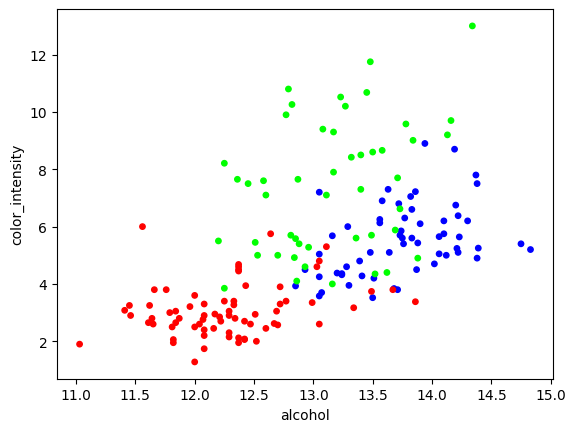

In [ ]:

import matplotlib.pyplot as plt
from sklearn import datasets

features = [0, 9]

wine = datasets.load_wine()
data = wine.data[:, features]
target = wine.target

plt.scatter(data[:, 0], data[:, 1], c=target, s=15, cmap=plt.cm.brg)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])

##Normalização

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)

##Instanciando sua rede

In [ ]:
import torch
from torch import nn

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(device)

input_size = data.shape[1]
hidden_size = 32
output_size = len(wine.target_names) #número de classes

net = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, output_size),
    nn.Softmax()
)

net = net.to(device)

cuda


##Visualizando a fronteira de decisão

In [ ]:
import numpy as np

def plot_boundary(X, y, model):
  x_min, x_max = X[:, 0].min()-0.1, X[:, 0].max()+0.1
  y_min, y_max = X[:, 1].min()-0.1, X[:, 1].max()+0.1

  spacing = min(x_max - x_min, y_max - y_min) / 100

  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing),
                       np.arange(y_min, y_max, spacing))

  data = np.hstack((XX.ravel().reshape(-1,1),
                    YY.ravel().reshape(-1,1)))

  # For binary problems
  # db_prob = model(Variable(torch.Tensor(data)).cuda() )
  # clf = np.where(db_prob.cpu().data < 0.5,0,1)

  # For multi-class problems
  db_prob = model(torch.Tensor(data).to(device) )
  clf = np.argmax(db_prob.cpu().data.numpy(), axis=-1)

  Z = clf.reshape(XX.shape)

  plt.contourf(XX, YY, Z, cmap=plt.cm.brg, alpha=0.5)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=25, cmap=plt.cm.brg)

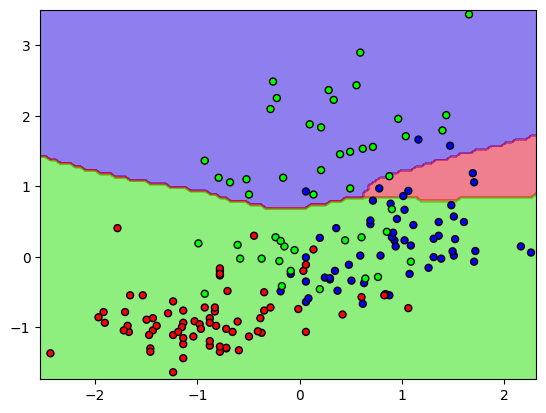

In [ ]:
plot_boundary(data, target, net)


In [ ]:
from torch import optim

#Função de Perda
criterion = nn.CrossEntropyLoss().to(device)

#Otimizador: Descida do Gradiente
#Stochastic Gradient Descent
optimizer = optim.SGD(net.parameters(), lr=1e-3)

In [ ]:
X = torch.FloatTensor(data).to(device) #GPU
Y = torch.LongTensor(target).to(device)

##Treinando um modelo

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


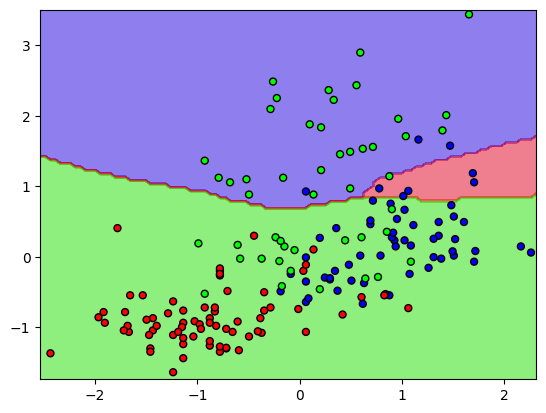

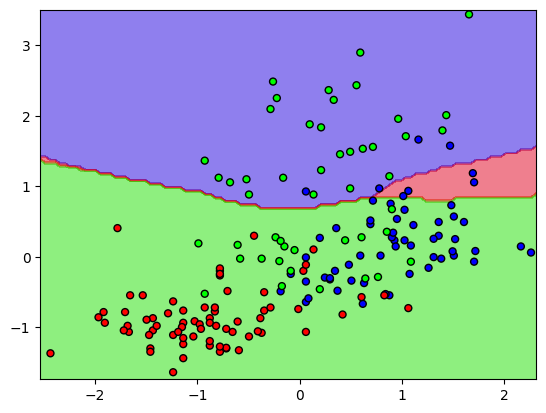

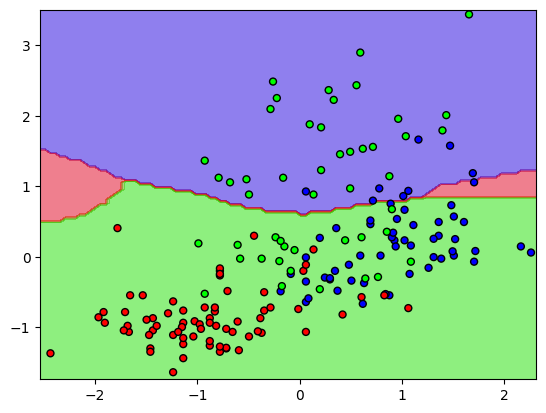

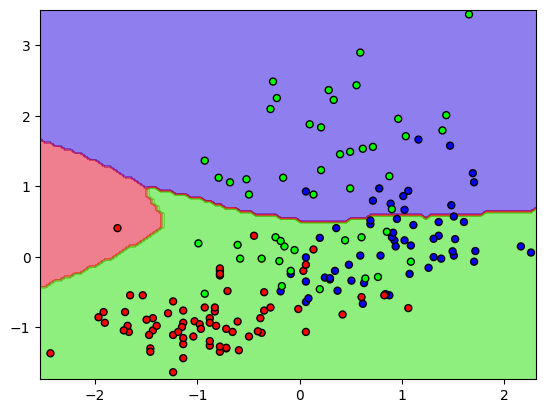

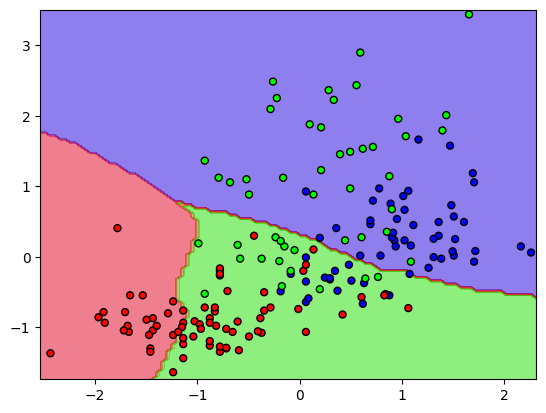

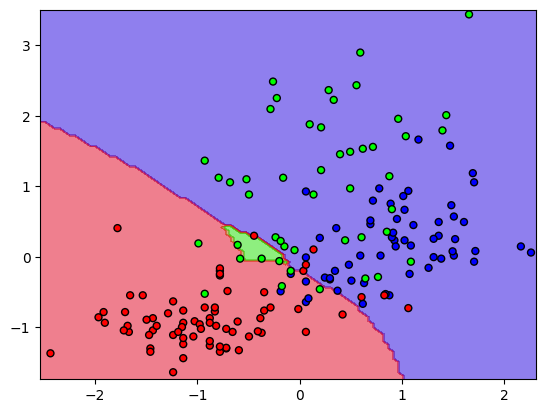

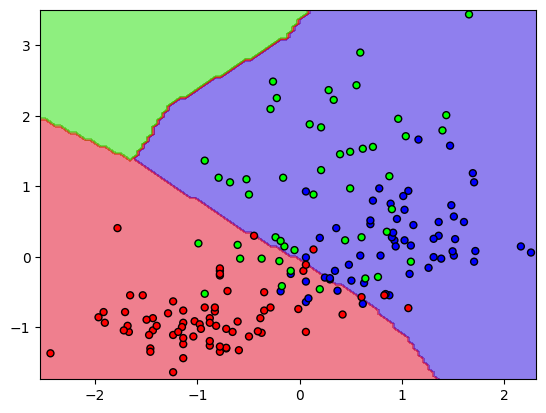

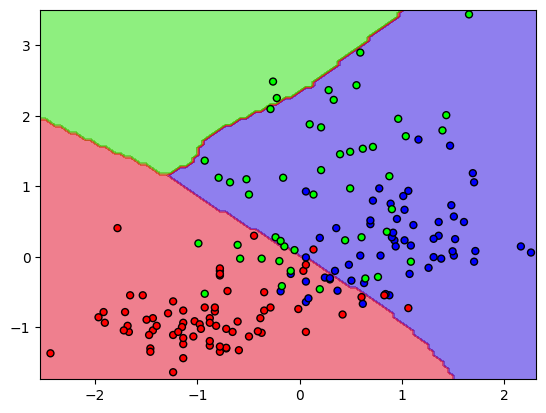

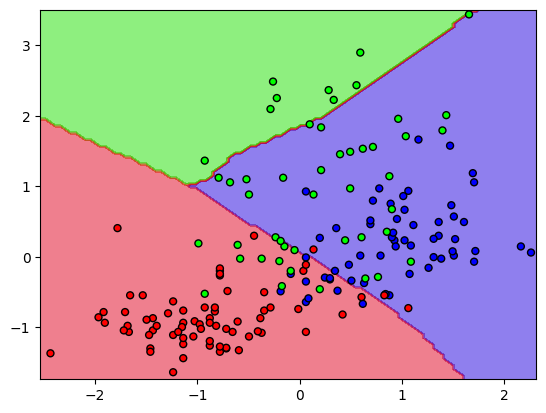

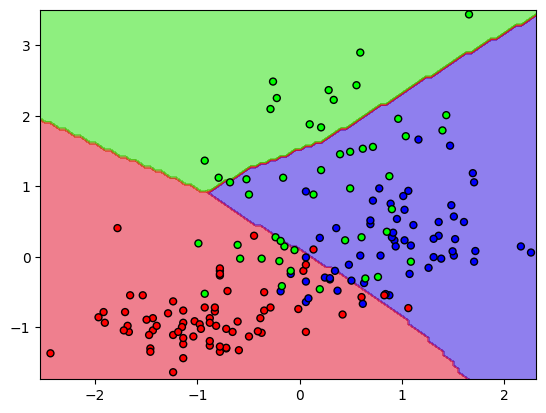

In [ ]:
for i in range(100):
  #Forward
  pred= net(X)
  loss = criterion(pred, Y)

  #Backpropagation
  loss.backward()
  optimizer.step()
  if i % 10 == 0:
    plt.figure()
    plot_boundary(data, target, net)

#**DataLoader e Fluxo de Treinamento**

In [ ]:
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
#Torchvision datasets
from torchvision import datasets
#Torchvision transforms
from torchvision import transforms
#DataLoader
from torch.utils.data import DataLoader

args =  {
    'batch_size': 20,
    'num_workers': 4,
    'lr': 1e-4,
    'weight_decay': 5e-4,
    'num_classes;': 10,
    'num_epochs': 30
}

if torch.cuda.is_available():
  args['device'] = torch.device('cuda')
else:
  args['device'] = torch.device('cpu')
print(args['device'])

cuda


##Datasets

In [ ]:
train_set = datasets.MNIST(root='./', train=True, download=True, transform=transforms.ToTensor())
test_set = datasets.MNIST(root='./', train=False, download=False, transform=transforms.ToTensor())

print('Amostra de treinos: ' + str(len(train_set)) + '\nAmostra de teste: ' + str(len(test_set)))

Amostra de treinos: 60000
Amostra de teste: 10000


In [ ]:
print(type(train_set))
print(type(train_set[0]))

<class 'torchvision.datasets.mnist.MNIST'>
<class 'tuple'>


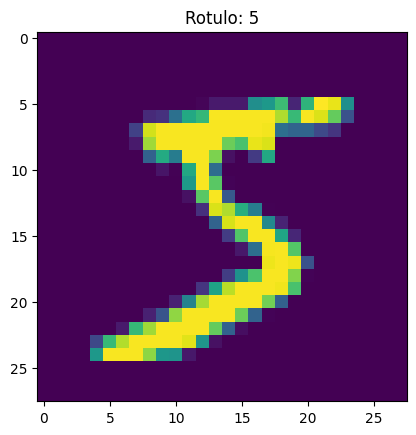

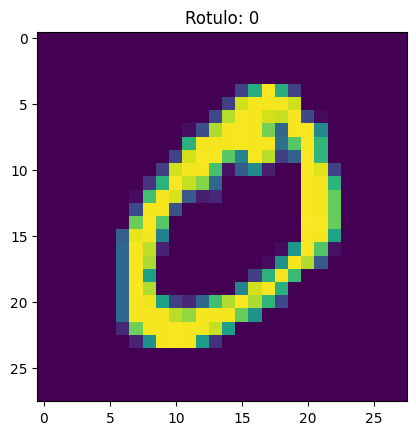

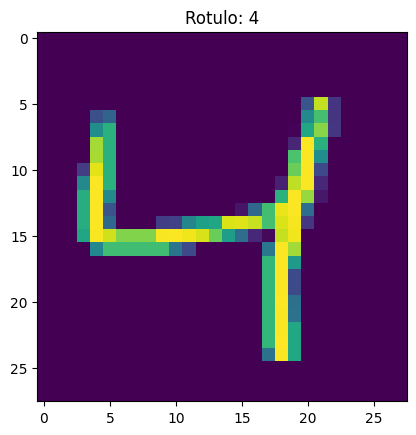

In [ ]:
for i in range(3):
  dado, rotulo = train_set[i]

  plt.figure()
  plt.imshow(dado[0])
  plt.title('Rotulo: ' + str(rotulo))

##DataLoader

In [ ]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True,
                          num_workers=args['num_workers'])

test_loader = DataLoader(test_set,
                         batch_size=args['batch_size'],
                         shuffle=True,
                         num_workers=args['num_workers'])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([20, 1, 28, 28]) torch.Size([20])


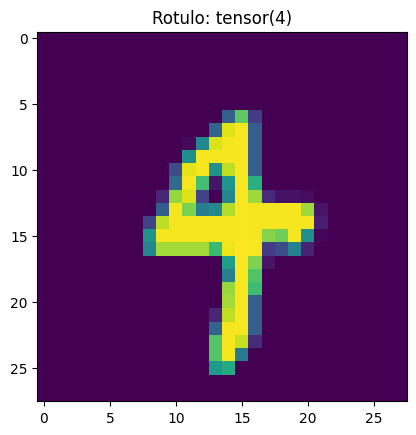

In [ ]:
for batch in train_loader:
  dado, rotulo = batch
  print(dado.size(), rotulo.size())

  plt.imshow(dado[0][0])
  plt.title('Rotulo: ' + str(rotulo[0]))
  break

In [ ]:
class MLP(nn.Module):

  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features  = nn.Sequential(
                      nn.Linear(input_size, hidden_size),
                      nn.ReLU(),
                      nn.Linear(hidden_size, hidden_size),
                      nn.ReLU()
                    )
    self.out     = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax()

  def forward(self, X):

    X = X.view(X.size(0), -1)

    feature = self.features(X)
    output  = self.softmax(self.out(feature))

    return output

input_size  = 28 * 28
hidden_size = 128
out_size    = 10 #classes

torch.manual_seed(42)
net = MLP(input_size, hidden_size, out_size).to(args['device']) #cast na GPU

In [ ]:
criterion = nn.CrossEntropyLoss().to(args['device'])
optimizer = optim.Adam(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

##Fluxo de treinamento

In [ ]:
for epoch in range(args['num_epochs']):

  epoch_loss = []
  for batch in train_loader:

    dado, rotulo = batch

    # Cast na GPU
    dado   = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    pred = net(dado)
    loss = criterion(pred, rotulo)
    epoch_loss.append(loss.cpu().data)

    # Backward
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)

  print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )

<>:23: SyntaxWarning: invalid escape sequence '\-'
<>:23: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_3019/3062481922.py:23: SyntaxWarning: invalid escape sequence '\-'
  print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )


Epoca 0, Loss: 1.7719 +\- 0.1065
Epoca 1, Loss: 1.7882 +\- 0.1049
Epoca 2, Loss: 1.8608 +\- 0.1110
Epoca 3, Loss: 1.8405 +\- 0.1117
Epoca 4, Loss: 1.8426 +\- 0.1106
Epoca 5, Loss: 1.9723 +\- 0.1234
Epoca 6, Loss: 2.0651 +\- 0.1099


KeyboardInterrupt: 

#**Datasets e Fluxo de Validação**

In [ ]:
import torch
from torch import nn, optim

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

args =  {
    'batch_size': 20,
    'num_workers': 4,
    'lr': 1e-4,
    'weight_decay': 5e-4,
    'num_classes;': 10,
    'num_epochs': 30
}

if torch.cuda.is_available():
  args['device'] = torch.device('cuda')
else:
  args['device'] = torch.device('cpu')
print(args['device'])

cuda


In [ ]:
#baixando datasets
! wget /content/bike+sharing+dataset.zip
! unzip /content/bike+sharing+dataset.zip

/content/bike+sharing+dataset.zip: Scheme missing.
Archive:  /content/bike+sharing+dataset.zip
replace Readme.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
! ls

bike+sharing+dataset.zip  day.csv  hour.csv  Readme.txt  sample_data


In [ ]:
#Visualizando os dados
df = pd.read_csv('/content/hour.csv')
print(len(df))
df.head()

17379


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
#Tratamento de dados
torch.manual_seed(1)
indices = torch.randperm(len(df)).tolist()

train_size = int(0.8*len(df))
df_train = df.iloc[indices[:train_size]]
df_test = df.iloc[indices[train_size:]]

print(len(df_train), len(df_test))
display(df_test.head())
df_train.to_csv('bike_train.csv', index=False)
df_test.to_csv('bike_test.csv', index=False)

!ls

13903 3476


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12663,12664,2012-06-16,2,1,6,20,0,6,0,2,0.66,0.6212,0.47,0.1940,123,229,352
1801,1802,2011-03-20,1,0,3,18,0,0,0,1,0.38,0.3939,0.40,0.3582,58,98,156
16567,16568,2012-11-28,4,1,11,1,0,3,1,2,0.26,0.2576,0.75,0.2239,0,12,12
8817,8818,2012-01-08,1,1,1,5,0,0,0,2,0.32,0.3333,0.49,0.1045,0,2,2
2608,2609,2011-04-23,2,0,4,14,0,6,0,1,0.58,0.5455,0.78,0.3582,182,209,391


bike+sharing+dataset.zip  bike_train.csv  hour.csv    sample_data
bike_test.csv		  day.csv	  Readme.txt


##Classe Dataset

In [ ]:
class Bicreta(Dataset):
  def __init__(self, csv_path):
    self.dados = pd.read_csv(csv_path).to_numpy()

  def __getitem__(self, idx):
    sample = self.dados[idx][2:14]
    label = self.dados[idx][-1:]

    #coverte pra tensor
    sample = torch.from_numpy(sample.astype(np.float32))
    label = torch.from_numpy(label.astype(np.float32))

    return sample, label

  def __len__(self):
    return len(self.dados)

In [ ]:
train_set = Bicreta('bike_train.csv')
test_set = Bicreta('bike_test.csv')

dado, rotulo = train_set[0]
print(rotulo)
print(dado)

tensor([373.])
tensor([ 4.0000,  1.0000, 11.0000, 19.0000,  0.0000,  4.0000,  1.0000,  1.0000,
         0.3800,  0.3939,  0.2700,  0.3582])


##Dataloader

In [ ]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True,
                          num_workers=args['num_workers'])

test_loader = DataLoader(test_set,
                         batch_size=args['batch_size'],
                         shuffle=True,
                         num_workers=args['num_workers'])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
for batch in train_loader:
  dado, rotulo = batch
  print(dado.size(), rotulo.size())

  break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([20, 12]) torch.Size([20, 1])


In [ ]:
#Implementando o mesmo MLP mas muda a saída
class MLP(nn.Module):

  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features  = nn.Sequential(
                      nn.Linear(input_size, hidden_size),
                      nn.ReLU(),
                      nn.Linear(hidden_size, hidden_size),
                      nn.ReLU()
                    )
    self.out     = nn.Linear(hidden_size, out_size)

  def forward(self, X):

    feature = self.features(X)
    output  = self.out(feature)

    return output

input_size  = len(train_set[0][0])
hidden_size = 128
out_size    = 10 #variáveis que serão preditas

net = MLP(input_size, hidden_size, out_size).to(args['device']) #cast na GPU

In [ ]:
criterion = nn.L1Loss().to(args['device'])
optimizer = optim.Adam(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

In [ ]:
def train(train_loader, net, epoch):
  epoch_loss = []
  for epoch in range(args['num_epochs']):

    epoch_loss = []
    for batch in train_loader:

      dado, rotulo = batch

      # Cast na GPU
      dado   = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      pred = net(dado)
      loss = criterion(pred, rotulo)
      epoch_loss.append(loss.cpu().data)

      # Backward
      loss.backward()
      optimizer.step()

    epoch_loss = np.asarray(epoch_loss)

    print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )

<>:25: SyntaxWarning: invalid escape sequence '\-'
<>:25: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2769/75051838.py:25: SyntaxWarning: invalid escape sequence '\-'
  print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )


In [ ]:
def train(train_loader, net, epoch):
  net.train()
  epoch_loss = []
  for epoch in range(args['num_epochs']):

    epoch_loss = []
    for batch in train_loader:

      dado, rotulo = batch

      # Cast na GPU
      dado   = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      pred = net(dado)
      loss = criterion(pred, rotulo)
      epoch_loss.append(loss.cpu().data)

      # Backward
      loss.backward()
      optimizer.step()

    epoch_loss = np.asarray(epoch_loss)

    print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )

<>:26: SyntaxWarning: invalid escape sequence '\-'
<>:26: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2769/3893649296.py:26: SyntaxWarning: invalid escape sequence '\-'
  print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )


In [ ]:
def test(test_loader, net, epoch):

  net.eval()
  with torch.no_grad():
    epoch_loss = []
    for epoch in range(args['num_epochs']):

      epoch_loss = []
      for batch in train_loader:

        dado, rotulo = batch

        # Cast na GPU
        dado   = dado.to(args['device'])
        rotulo = rotulo.to(args['device'])

        # Forward
        pred = net(dado)
        loss = criterion(pred, rotulo)
        epoch_loss.append(loss.cpu().data)

      epoch_loss = np.asarray(epoch_loss)

      print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )

<>:24: SyntaxWarning: invalid escape sequence '\-'
<>:24: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2769/2664056296.py:24: SyntaxWarning: invalid escape sequence '\-'
  print("Epoca %d, Loss: %.4f +\- %.4f" % (epoch, epoch_loss.mean(), epoch_loss.std()) )


In [ ]:
for epoch in range(args['num_epochs']):
  train(train_loader, net, epoch)
  test(test_loader, net, epoch)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoca 0, Loss: 78.0530 +\- 20.8710


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([3, 1])) that is different to the input size (torch.Size([3, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoca 1, Loss: 77.6069 +\- 20.3630
Epoca 2, Loss: 78.2711 +\- 21.0060
Epoca 3, Loss: 76.4971 +\- 20.5319
Epoca 4, Loss: 76.9586 +\- 21.9003
Epoca 5, Loss: 76.9783 +\- 21.3164
Epoca 6, Loss: 76.9708 +\- 21.3419
Epoca 7, Loss: 76.7530 +\- 22.7021
Epoca 8, Loss: 75.3064 +\- 20.4989
Epoca 9, Loss: 75.3247 +\- 21.1276
Epoca 10, Loss: 74.5890 +\- 20.0592
Epoca 11, Loss: 73.4512 +\- 20.5865
Epoca 12, Loss: 73.5473 +\- 21.2304
Epoca 13, Loss: 71.9497 +\- 19.4562
Epoca 14, Loss: 71.4861 +\- 21.5830
Epoca 15, Loss: 71.8844 +\- 19.8211
Epoca 16, Loss: 70.7202 +\- 20.2535
Epoca 17, Loss: 70.5284 +\- 19.9219
Epoca 18, Loss: 70.0609 +\- 20.4939
Epoca 19, Loss: 70.7825 +\- 19.7418
Epoca 20, Loss: 71.1432 +\- 21.2222
Epoca 21, Loss: 70.5176 +\- 21.1183
Epoca 22, Loss: 70.0990 +\- 20.5347
Epoca 23, Loss: 70.2328 +\- 19.6702
Epoca 24, Loss: 69.9100 +\- 19.0380
Epoca 25, Loss: 69.8548 +\- 20.5162
Epoca 26, Loss: 69.5024 +\- 20.4311
Epoca 27, Loss: 69.5109 +\- 19.4622
Epoca 28, Loss: 69.1334 +\- 19.4397
E